# plot145


# DES

Removed no burn in
Saved: /home/geng/Codes/lensing_cosmo/jax01/output_des_sim/getdist_des_sim_wcdm.png
Removed no burn in
Saved: /home/geng/Codes/lensing_cosmo/jax01/output_des_sim/getdist_des_sim_w0wa.png


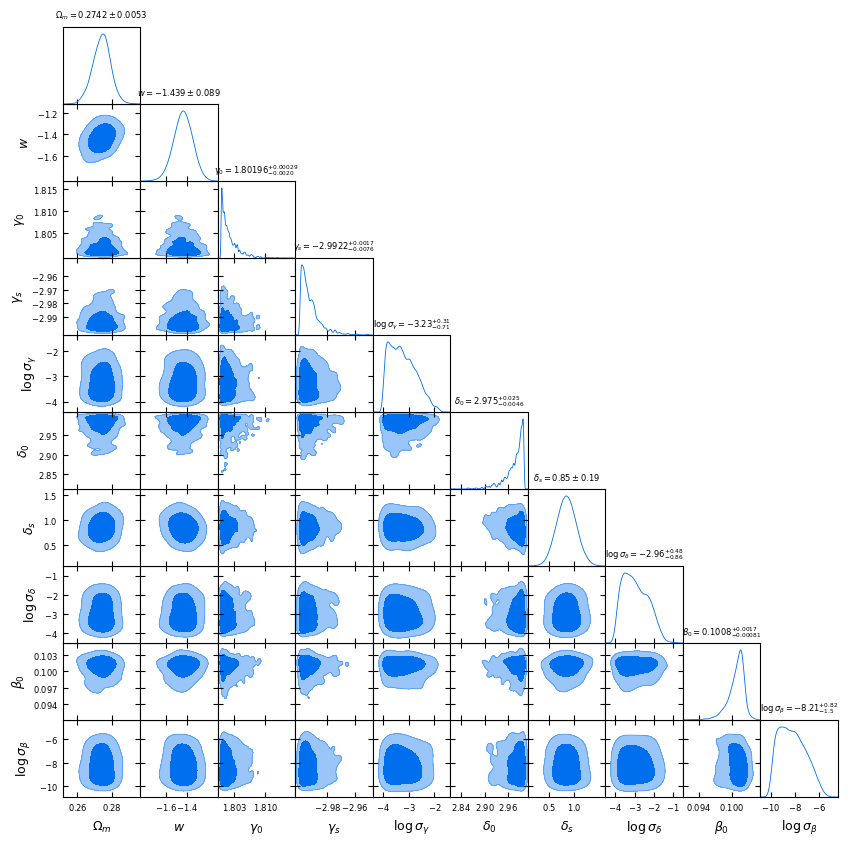

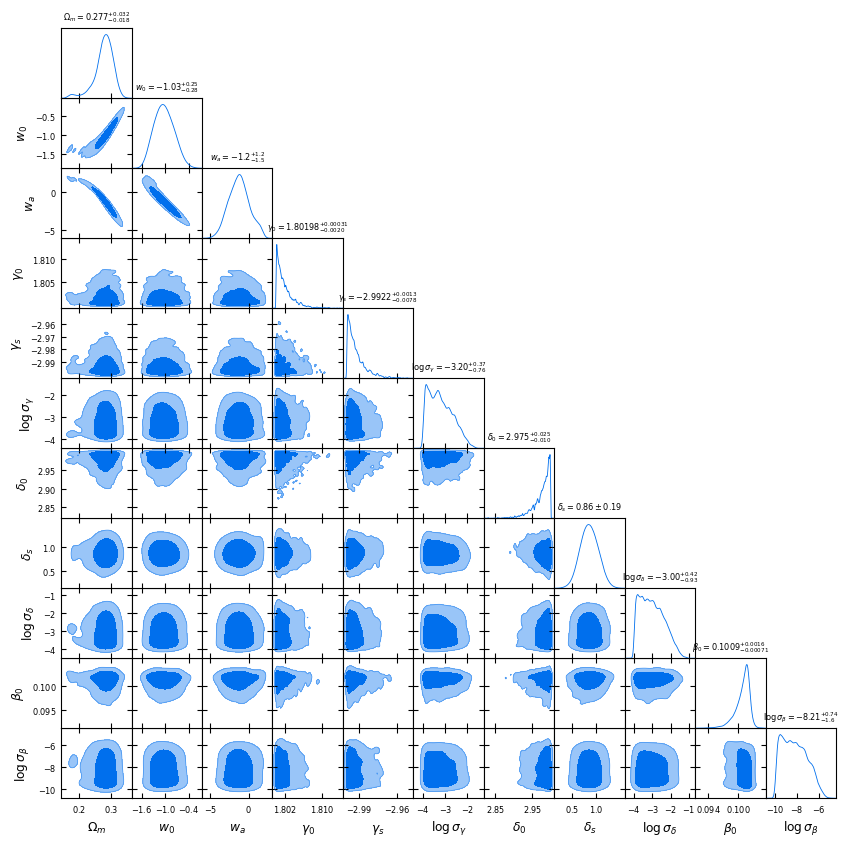

In [1]:
import os
import numpy as np
from getdist import MCSamples, plots as gdplots

BASE_OUT = "/home/geng/Codes/lensing_cosmo/jax01/output_des_sim"
full_labels = {
    "wcdm": "des_sim_wcdm",
    "w0wa": "des_sim_w0wa",
}

tail_keys = [
    "gamma0", "gamma_s", "log_sig_g",
    "delta0", "delta_s", "log_sig_d",
    "beta0", "log_sig_b",
]

def head_keys_for(model):
    if model == "wcdm":
        return ["Om", "w"]
    if model == "w0wa":
        return ["Om", "w0", "wa"]
    raise ValueError(f"unknown model: {model}")

def load_samples(npz_path, keys):
    data = np.load(npz_path)
    missing = [k for k in keys if k not in data.files]
    if missing:
        raise KeyError(f"npz missing keys: {missing}\navailable: {list(data.files)}")
    return np.vstack([data[k] for k in keys]).T

name_map = {
    "Om": "Om", "w": "w", "w0": "w0", "wa": "wa",
    "gamma0": "gamma0", "gamma_s": "gamma_s", "log_sig_g": "log_sig_g",
    "delta0": "delta0", "delta_s": "delta_s", "log_sig_d": "log_sig_d",
    "beta0": "beta0", "log_sig_b": "log_sig_b",
}
label_map = {
    "Om": r"\Omega_m", "w": r"w", "w0": r"w_0", "wa": r"w_a",
    "gamma0": r"\gamma_0", "gamma_s": r"\gamma_s", "log_sig_g": r"\log\sigma_\gamma",
    "delta0": r"\delta_0", "delta_s": r"\delta_s", "log_sig_d": r"\log\sigma_\delta",
    "beta0": r"\beta_0", "log_sig_b": r"\log\sigma_\beta",
}

for model, label in full_labels.items():
    npz_path = os.path.join(BASE_OUT, f"posterior_minimal_chunks_{label}.npz")
    keys = head_keys_for(model) + tail_keys
    samples = load_samples(npz_path, keys)

    burn = int(0.2 * samples.shape[0])
    samples2 = samples[burn:]

    names = [name_map[k] for k in keys]
    labels = [label_map.get(k, k) for k in keys]

    mc = MCSamples(samples=samples2, names=names, labels=labels, label=label)
    g = gdplots.get_subplot_plotter(width_inch=10)
    g.triangle_plot([mc], filled=True, title_limit=1)

    out_path = os.path.join(BASE_OUT, f"getdist_{label}.png")
    g.export(out_path)
    print("Saved:", out_path)


In [ ]:
import os
import numpy as np
from getdist import MCSamples, plots as gdplots

BASE_OUT = "/home/geng/Codes/lensing_cosmo/jax01/output_des_sim"
full_labels = {
    "wcdm": "des_sim_wcdm",
    "w0wa": "des_sim_w0wa",
}

tail_keys = [
    "gamma0", "gamma_s", "log_sig_g",
    "delta0", "delta_s", "log_sig_d",
    "beta0", "log_sig_b",
]

def head_keys_for(model):
    if model == "wcdm":
        return ["Om", "w"]
    if model == "w0wa":
        return ["Om", "w0", "wa"]
    raise ValueError(f"unknown model: {model}")

def load_samples(npz_path, keys):
    data = np.load(npz_path)
    missing = [k for k in keys if k not in data.files]
    if missing:
        raise KeyError(f"npz missing keys: {missing}\navailable: {list(data.files)}")
    return np.vstack([data[k] for k in keys]).T

def peak_q16_q84(x, bins=200):
    hist, edges = np.histogram(x, bins=bins, density=True)
    i = int(np.argmax(hist))
    peak = 0.5 * (edges[i] + edges[i+1])
    q16, q84 = np.quantile(x, [0.16, 0.84])
    return float(peak), float(q16), float(q84)

name_map = {
    "Om": "Om", "w": "w", "w0": "w0", "wa": "wa",
    "gamma0": "gamma0", "gamma_s": "gamma_s", "log_sig_g": "log_sig_g",
    "delta0": "delta0", "delta_s": "delta_s", "log_sig_d": "log_sig_d",
    "beta0": "beta0", "log_sig_b": "log_sig_b",
}
label_map = {
    "Om": r"\Omega_m", "w": r"w", "w0": r"w_0", "wa": r"w_a",
    "gamma0": r"\gamma_0", "gamma_s": r"\gamma_s", "log_sig_g": r"\log\sigma_\gamma",
    "delta0": r"\delta_0", "delta_s": r"\delta_s", "log_sig_d": r"\log\sigma_\delta",
    "beta0": r"\beta_0", "log_sig_b": r"\log\sigma_\beta",
}

for model, label in full_labels.items():
    npz_path = os.path.join(BASE_OUT, f"posterior_minimal_chunks_{label}.npz")
    keys = head_keys_for(model) + tail_keys
    samples = load_samples(npz_path, keys)

    burn = int(0.2 * samples.shape[0])
    samples2 = samples[burn:]

    names = [name_map[k] for k in keys]
    labels = [label_map.get(k, k) for k in keys]

    mc = MCSamples(samples=samples2, names=names, labels=labels, label=label)
    g = gdplots.get_subplot_plotter(width_inch=10)
    g.triangle_plot([mc], filled=True, title_limit=0)

    for i, k in enumerate(keys):
        peak, q16, q84 = peak_q16_q84(samples2[:, i])
        dminus = peak - q16
        dplus = q84 - peak
        ax = g.subplots[i, i]
        ax.set_title(rf"${peak:.3f}_{{-{dminus:.3f}}}^{{+{dplus:.3f}}}$", fontsize=10)

    out_path = os.path.join(BASE_OUT, f"getdist_peak_{label}.png")
    g.export(out_path)
    print("Saved:", out_path)



# LSST

Removed no burn in
Saved: /home/geng/Codes/lensing_cosmo/jax01/output_lsst_sim/getdist_lsst145_wcdm.png
Removed no burn in
Saved: /home/geng/Codes/lensing_cosmo/jax01/output_lsst_sim/getdist_lsst145_w0wa.png


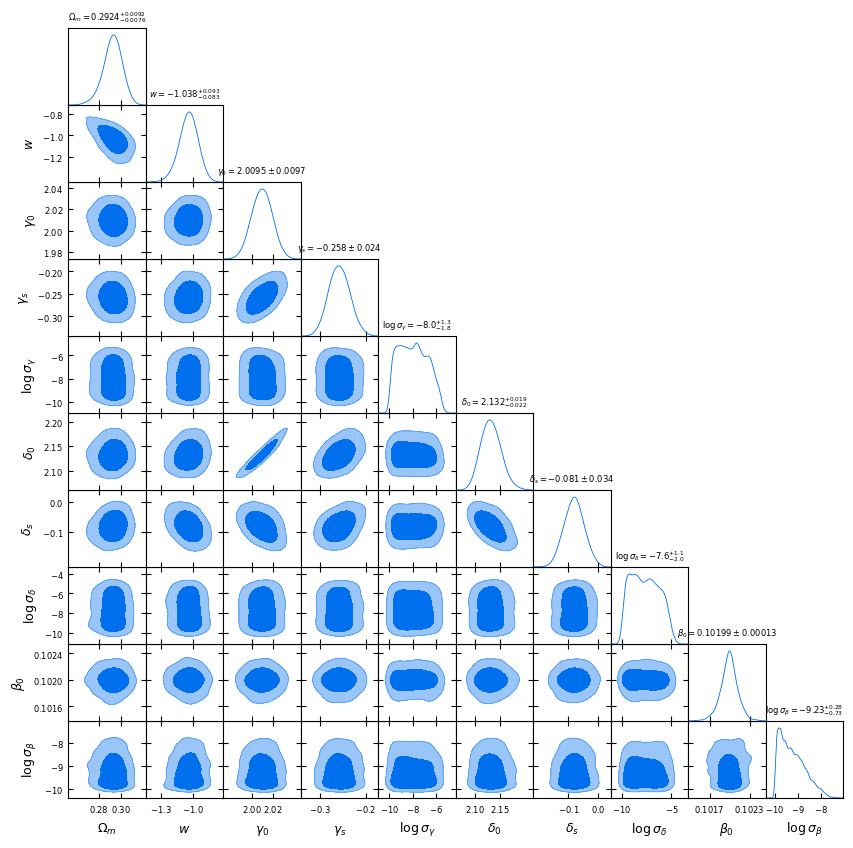

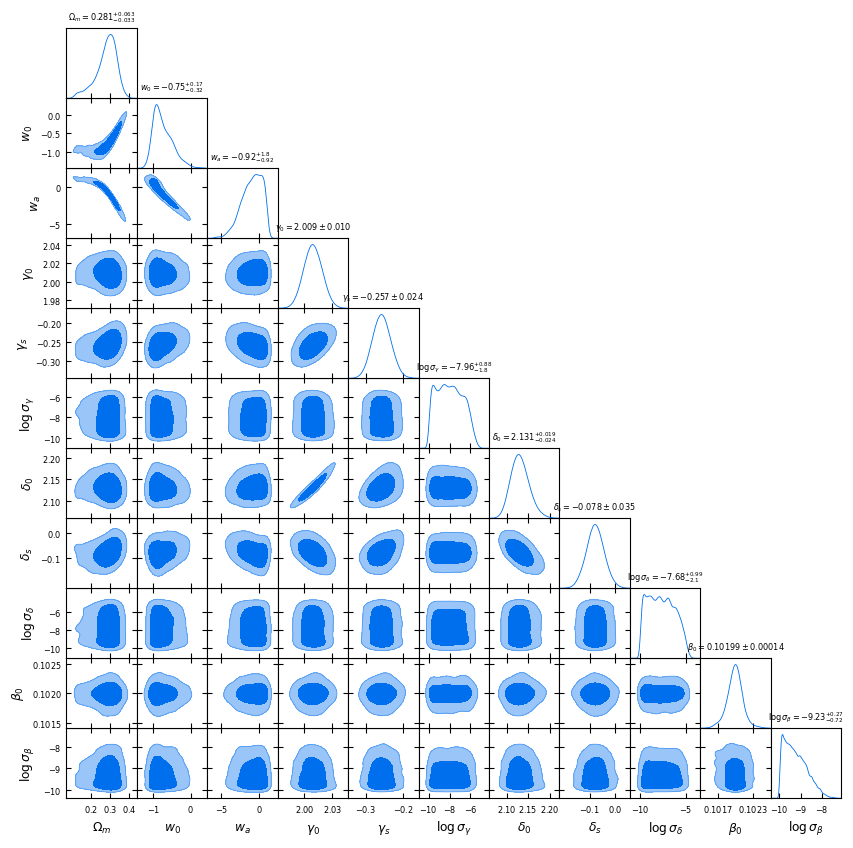

In [5]:
import os
import numpy as np
from getdist import MCSamples, plots as gdplots

BASE_OUT = "/home/geng/Codes/lensing_cosmo/jax01/output_lsst_sim"
full_labels = {
    "wcdm": "lsst145_wcdm",
    "w0wa": "lsst145_w0wa",
}

tail_keys = [
    "gamma0", "gamma_s", "log_sig_g",
    "delta0", "delta_s", "log_sig_d",
    "beta0", "log_sig_b",
]

def head_keys_for(model):
    if model == "wcdm":
        return ["Om", "w"]
    if model == "w0wa":
        return ["Om", "w0", "wa"]
    raise ValueError(f"unknown model: {model}")

def load_samples(npz_path, keys):
    data = np.load(npz_path)
    missing = [k for k in keys if k not in data.files]
    if missing:
        raise KeyError(f"npz missing keys: {missing}\navailable: {list(data.files)}")
    return np.vstack([data[k] for k in keys]).T

name_map = {
    "Om": "Om", "w": "w", "w0": "w0", "wa": "wa",
    "gamma0": "gamma0", "gamma_s": "gamma_s", "log_sig_g": "log_sig_g",
    "delta0": "delta0", "delta_s": "delta_s", "log_sig_d": "log_sig_d",
    "beta0": "beta0", "log_sig_b": "log_sig_b",
}
label_map = {
    "Om": r"\Omega_m", "w": r"w", "w0": r"w_0", "wa": r"w_a",
    "gamma0": r"\gamma_0", "gamma_s": r"\gamma_s", "log_sig_g": r"\log\sigma_\gamma",
    "delta0": r"\delta_0", "delta_s": r"\delta_s", "log_sig_d": r"\log\sigma_\delta",
    "beta0": r"\beta_0", "log_sig_b": r"\log\sigma_\beta",
}

for model, label in full_labels.items():
    npz_path = os.path.join(BASE_OUT, f"posterior_minimal_chunks_{label}.npz")
    keys = head_keys_for(model) + tail_keys
    samples = load_samples(npz_path, keys)

    burn = int(0.5 * samples.shape[0])
    samples2 = samples[burn:]

    names = [name_map[k] for k in keys]
    labels = [label_map.get(k, k) for k in keys]

    mc = MCSamples(samples=samples2, names=names, labels=labels, label=label)
    g = gdplots.get_subplot_plotter(width_inch=10)
    g.triangle_plot([mc], filled=True, title_limit=1)

    out_path = os.path.join(BASE_OUT, f"getdist_{label}.png")
    g.export(out_path)
    print("Saved:", out_path)


Removed no burn in
Saved: /home/geng/Codes/lensing_cosmo/jax01/output_lsst_sim/getdist_peak_lsst145_wcdm.png
Removed no burn in
Saved: /home/geng/Codes/lensing_cosmo/jax01/output_lsst_sim/getdist_peak_lsst145_w0wa.png


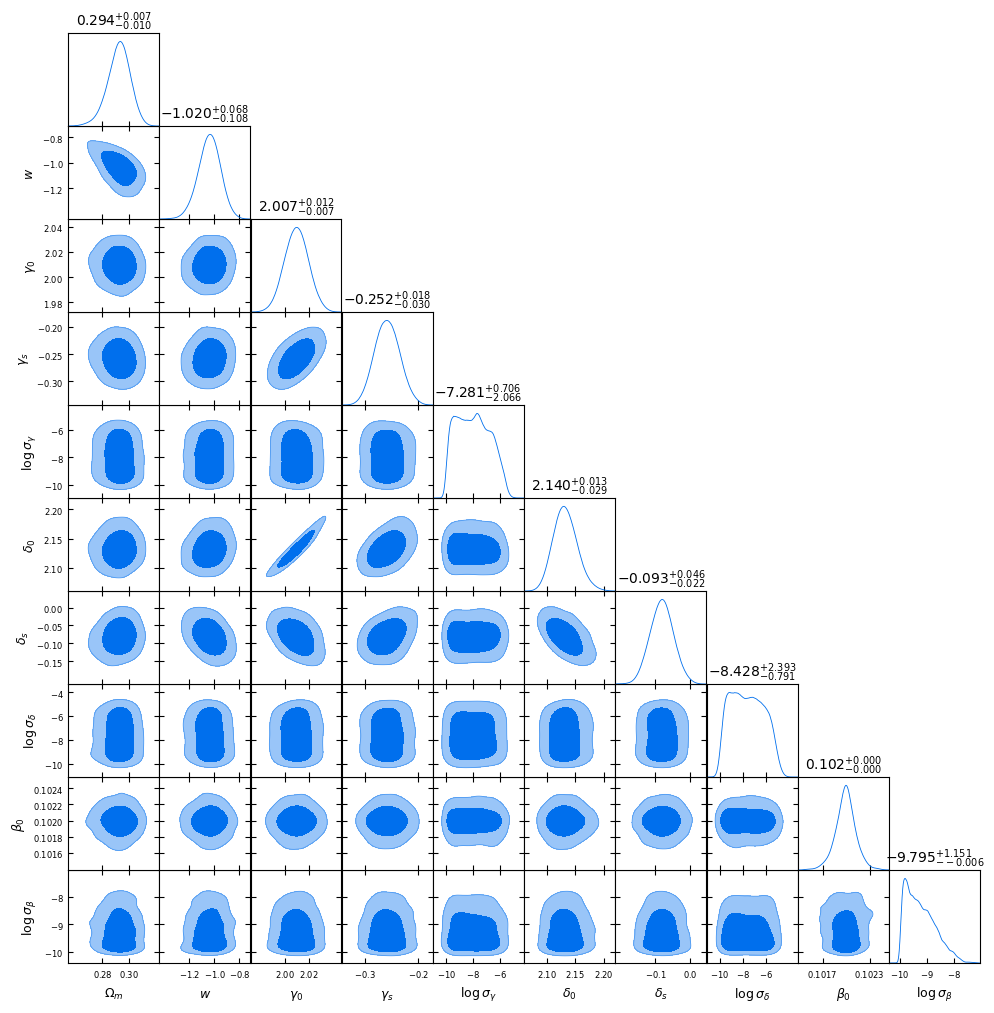

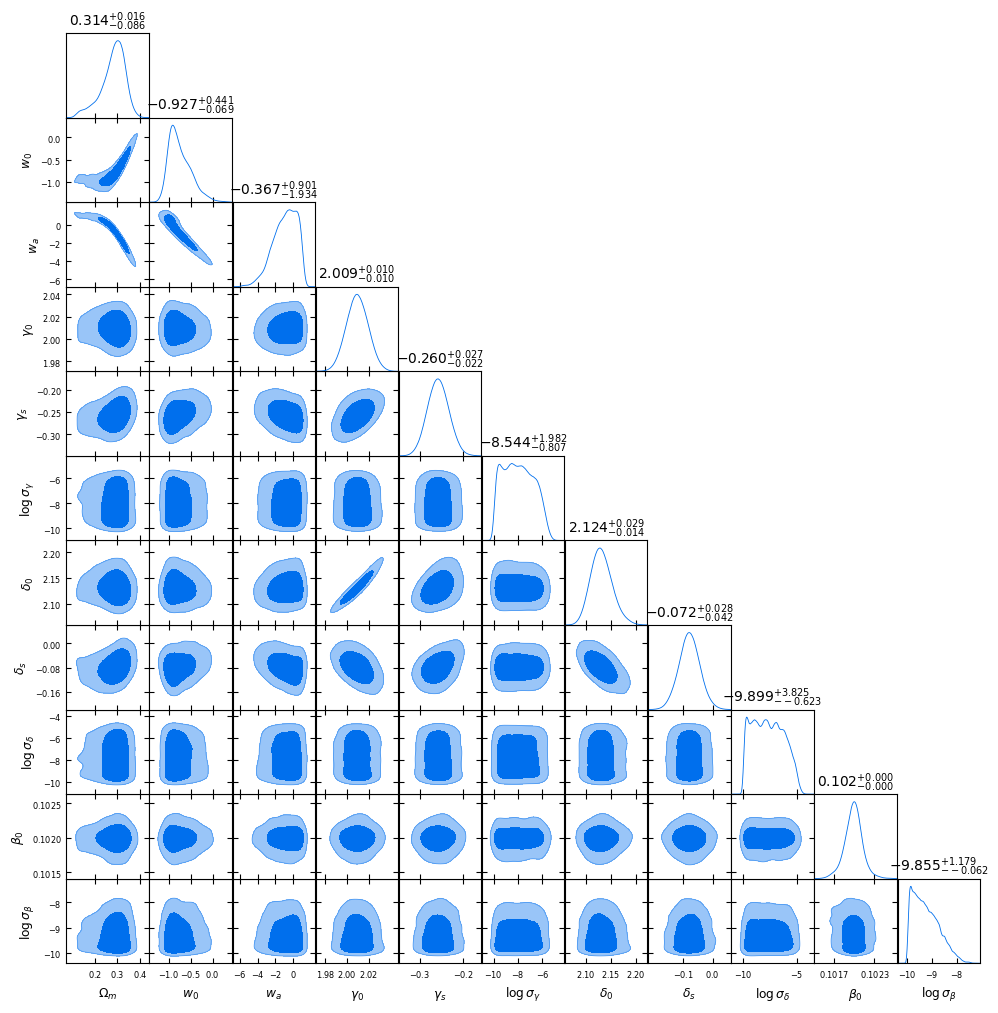

In [2]:
import os
import numpy as np
from getdist import MCSamples, plots as gdplots

BASE_OUT = "/home/geng/Codes/lensing_cosmo/jax01/output_lsst_sim"
full_labels = {
    "wcdm": "lsst145_wcdm",
    "w0wa": "lsst145_w0wa",
}

tail_keys = [
    "gamma0", "gamma_s", "log_sig_g",
    "delta0", "delta_s", "log_sig_d",
    "beta0", "log_sig_b",
]

def head_keys_for(model):
    if model == "wcdm":
        return ["Om", "w"]
    if model == "w0wa":
        return ["Om", "w0", "wa"]
    raise ValueError(f"unknown model: {model}")

def load_samples(npz_path, keys):
    data = np.load(npz_path)
    missing = [k for k in keys if k not in data.files]
    if missing:
        raise KeyError(f"npz missing keys: {missing}\navailable: {list(data.files)}")
    return np.vstack([data[k] for k in keys]).T

def peak_q16_q84(x, bins=200):
    hist, edges = np.histogram(x, bins=bins, density=True)
    i = int(np.argmax(hist))
    peak = 0.5 * (edges[i] + edges[i+1])
    q16, q84 = np.quantile(x, [0.16, 0.84])
    return float(peak), float(q16), float(q84)

name_map = {
    "Om": "Om", "w": "w", "w0": "w0", "wa": "wa",
    "gamma0": "gamma0", "gamma_s": "gamma_s", "log_sig_g": "log_sig_g",
    "delta0": "delta0", "delta_s": "delta_s", "log_sig_d": "log_sig_d",
    "beta0": "beta0", "log_sig_b": "log_sig_b",
}
label_map = {
    "Om": r"\Omega_m", "w": r"w", "w0": r"w_0", "wa": r"w_a",
    "gamma0": r"\gamma_0", "gamma_s": r"\gamma_s", "log_sig_g": r"\log\sigma_\gamma",
    "delta0": r"\delta_0", "delta_s": r"\delta_s", "log_sig_d": r"\log\sigma_\delta",
    "beta0": r"\beta_0", "log_sig_b": r"\log\sigma_\beta",
}

for model, label in full_labels.items():
    npz_path = os.path.join(BASE_OUT, f"posterior_minimal_chunks_{label}.npz")
    keys = head_keys_for(model) + tail_keys
    samples = load_samples(npz_path, keys)

    burn = int(0.4 * samples.shape[0])
    samples2 = samples[burn:]

    names = [name_map[k] for k in keys]
    labels = [label_map.get(k, k) for k in keys]

    mc = MCSamples(samples=samples2, names=names, labels=labels, label=label)
    g = gdplots.get_subplot_plotter(width_inch=10)
    g.triangle_plot([mc], filled=True, title_limit=0)

    for i, k in enumerate(keys):
        peak, q16, q84 = peak_q16_q84(samples2[:, i])
        dminus = peak - q16
        dplus = q84 - peak
        ax = g.subplots[i, i]
        ax.set_title(rf"${peak:.3f}_{{-{dminus:.3f}}}^{{+{dplus:.3f}}}$", fontsize=10)

    out_path = os.path.join(BASE_OUT, f"getdist_peak_{label}.png")
    g.export(out_path)
    print("Saved:", out_path)

